# DO Masked Card Classifier Test Notebook

Run scene segmentation, detect card crops, classify each crop with a mask-conditioned classifier, and group predictions with fixed UNO geometry (`p1` bottom, `p2` right, `p3` top, `p4` left, center in the middle).

## Inference conventions

- This notebook is inference/evaluation only.
- It loads:
  - `project/models/scene_segmenter_unet_small.pth`
  - `project/models/card_classifier_masked_resnet18_do.pth`
  - `project/models/card_classifier_masked_resnet18_classes_do.npy`
  - `project/models/card_classifier_masked_resnet18_config_do.json`
- It does not use pretrained external weights and keeps the existing competition-compliant geometry mapping.

In [1]:
from pathlib import Path
import sys

candidate_src_dirs = [
    Path.cwd() / "src",
    Path.cwd().parent.parent / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.is_dir():
        parent = src_dir.parent.resolve()
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate do/src directory for imports.")


from src.test_classifier_CNN import (
    TestPipelineConfig,
    initialize_test_pipeline,
    run_labeled_benchmark,
    run_single_image_diagnostics,
)

# In Cell 1, under other imports from src:
from src.shared.active_player import detect_active_player

# Most-used quick knobs
IMAGE_SOURCE = "augmented_scene"
IMAGE_INDEX = 0
IMAGE_ID = None
SEGMENTATION_THRESHOLD = 0.50
CARD_MASK_THRESHOLD = 0.50
CARD_IMG_SIZE = 160
SEGMENTER_IMG_SIZE = 256
# Manual area filter on connected mask components (in pixels).
SEGMENTER_MIN_COMPONENT_AREA = 6000

EVAL_MAX_IMAGES = None
EVAL_RANDOM_SUBSET = True
EVAL_SEED = 42
WORST_K = 7
TOP_K = 7
INSTANCE_MASK_GROWTH_PX = 10

TEST_CFG = TestPipelineConfig(
    image_source=IMAGE_SOURCE,
    image_index=IMAGE_INDEX,
    image_id=IMAGE_ID,
    card_img_size=CARD_IMG_SIZE,
    segmenter_img_size=SEGMENTER_IMG_SIZE,
    card_mask_threshold=CARD_MASK_THRESHOLD,
    segmenter_min_component_area=SEGMENTER_MIN_COMPONENT_AREA,
    instance_mask_growth_px=INSTANCE_MASK_GROWTH_PX,
    eval_threshold=SEGMENTATION_THRESHOLD,
)

BENCHMARK_CFG = {
    "eval_max_images": EVAL_MAX_IMAGES,
    "eval_random_subset": EVAL_RANDOM_SUBSET,
    "eval_seed": EVAL_SEED,
    "eval_threshold": TEST_CFG.eval_threshold,
    "worst_k": WORST_K,
    "top_k": TOP_K,
}

TEST_CFG

TestPipelineConfig(image_source='augmented_scene', image_index=0, image_id=None, card_img_size=160, segmenter_img_size=256, card_mask_threshold=0.5, segmenter_min_component_area=6000, instance_mask_growth_px=10, eval_threshold=0.5)

## Shared Helpers

In [2]:
test_state = initialize_test_pipeline(TEST_CFG)
{
    "image_id": test_state["image_id"],
    "image_path": str(test_state["image_path"]),
    "image_shape": (test_state["image_w"], test_state["image_h"]),
}

Project root: C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do
Segmenter:    C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\models\segmenter\used\scene_segmenter_unet_small.pth
Classifier bundle: C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\models\card_classifier_cnn\used\latest
Classifier:   C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\models\card_classifier_cnn\used\latest\card_classifier.pth
[compliance] SceneUNetSmall (segmenter): 1,928,417 trainable params
[compliance] CardClassifier[resnet18_small]: 9,853,134 trainable params
Loaded masked classifier with 54 classes.
Classifier architecture: resnet18_small (stem_width=60)
Card image size: 160 | mask threshold: 0.5 | segmenter min component area: 6000 | instance mask growth: 10px | input channels: 4
Device: cuda
Image source: augmented_scene
Image id:     aug_scene_00000
Image shape:  1280 x 720
Truth cards:  11, active: p1


{'image_id': 'aug_scene_00000',
 'image_path': 'C:\\Users\\UdaRe\\OneDrive\\Documenti\\GitHub\\iapr2026do\\project\\training_data\\training_images\\augmented_scenes\\aug_scene_00000.jpg',
 'image_shape': (1280, 720)}

In [3]:
import cv2

# 1. Load the current image from the test state path
img_path = test_state["image_path"]
img_bgr = cv2.imread(str(img_path))

if img_bgr is not None:
    # 2. Run active player detection
    predicted_player = detect_active_player(img_bgr)
    
    # 3. Print results alongside ground truth if available in test_state
    print(f"Predicted Active Player: {predicted_player}")
    # If the ground truth exists in your metadata structure, print it to verify accuracy:
    # print(f"Ground Truth Active Player: {test_state.get('active_player_ground_truth', 'N/A')}")
else:
    print(f"Failed to load image from path: {img_path}")

Predicted Active Player: unknown


## Segmenter Helpers

Detected boxes: 9
Foreground pixels: 105410


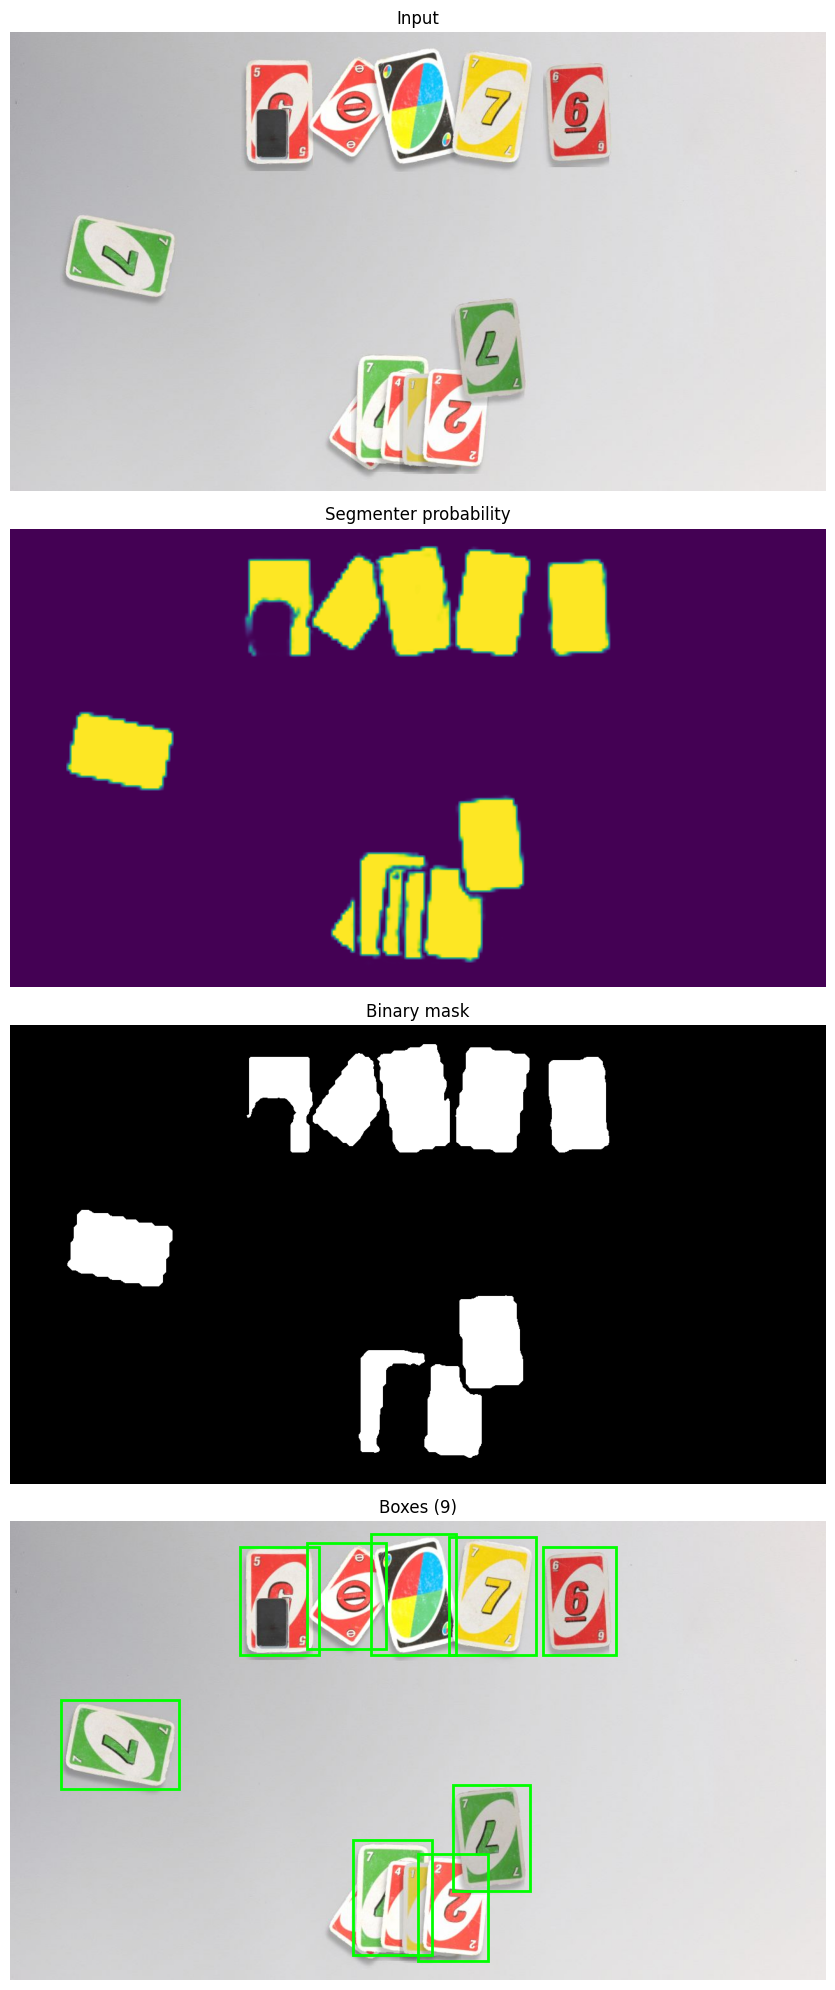

Predictions:
  box 00 (80, 280, 265, 420) -> g_7 [p4] conf=0.31 mask_cov=0.42
  box 01 (566, 20, 700, 210) -> wild [p3] conf=0.95 mask_cov=0.41
  box 02 (689, 25, 825, 210) -> y_7 [p3] conf=0.38 mask_cov=0.44
  box 03 (537, 500, 661, 681) -> draw_4 [p1] conf=0.21 mask_cov=0.27
  box 04 (361, 40, 485, 210) -> r_6 [p3] conf=0.47 mask_cov=0.36
  box 05 (465, 34, 590, 200) -> r_skip [p3] conf=0.24 mask_cov=0.35
  box 06 (695, 414, 815, 580) -> g_7 [center] conf=0.53 mask_cov=0.47
  box 07 (835, 40, 950, 210) -> r_6 [p3] conf=0.53 mask_cov=0.43
  box 08 (640, 522, 750, 689) -> r_reverse [p1] conf=0.37 mask_cov=0.39


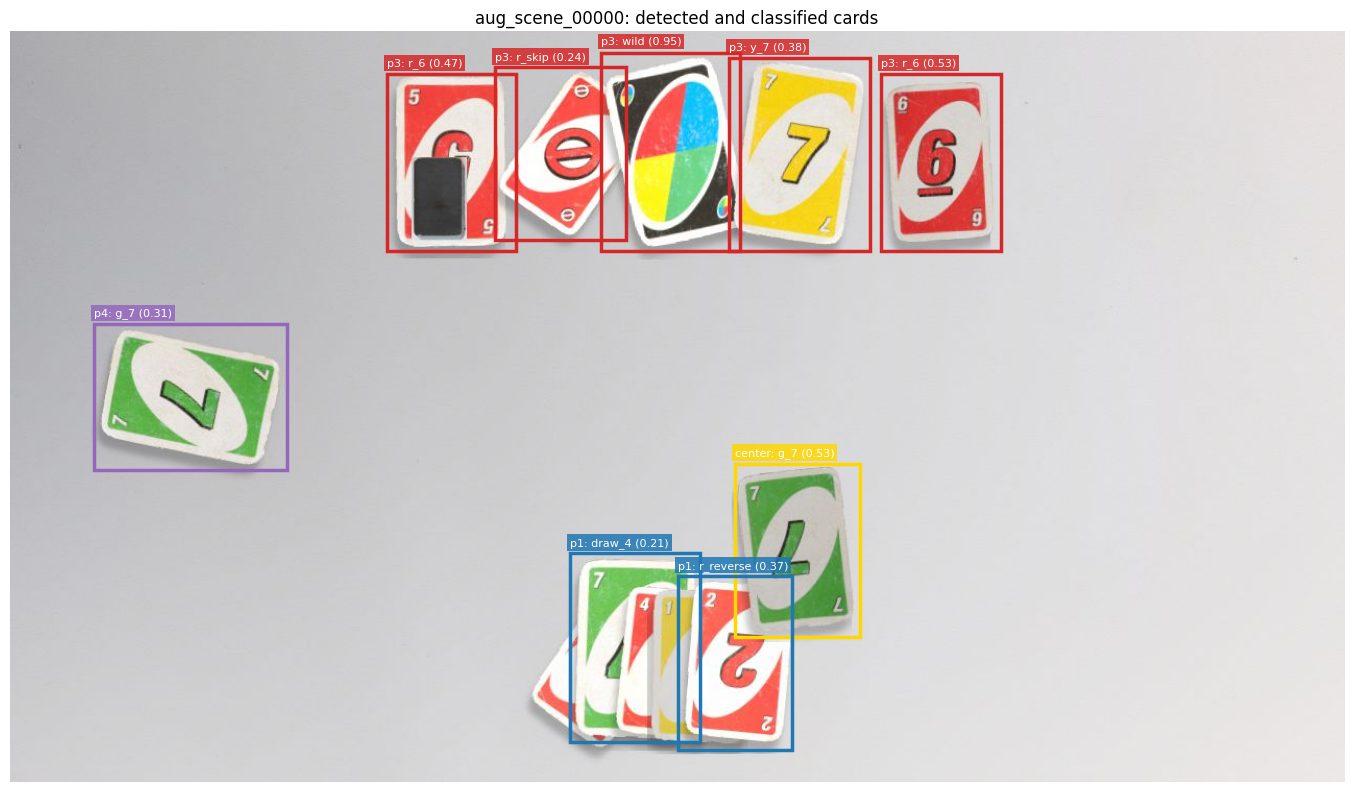


Matched IoU >= 0.30: 6 / 9
Label accuracy on matched boxes:        0.0%
Owner/region accuracy on matched boxes: 100.0%

First matched rows:
  pred=p4     g_7          | truth=p4     g_reverse    | IoU=0.37
  pred=p3     wild         | truth=p3     r_skip       | IoU=0.61
  pred=p3     y_7          | truth=p3     y_5          | IoU=0.74
  pred=p1     draw_4       | truth=p2     b_4          | IoU=0.00
  pred=p3     r_6          | truth=p3     b_8          | IoU=0.59
  pred=p3     r_skip       | truth=p3     y_3          | IoU=0.73
  pred=center g_7          | truth=p2     b_4          | IoU=0.00
  pred=p3     r_6          | truth=p3     wild         | IoU=0.62
  pred=p1     r_reverse    | truth=p2     b_4          | IoU=0.00
image_id: aug_scene_00000
center_card: g_7
active_player: p1
player_1_cards: draw_4;r_reverse
player_2_cards: EMPTY
player_3_cards: wild;y_7;r_6;r_skip;r_6
player_4_cards: g_7


{'image_id': 'aug_scene_00000',
 'center_card': 'g_7',
 'active_player': 'p1',
 'player_1_cards': 'draw_4;r_reverse',
 'player_2_cards': 'EMPTY',
 'player_3_cards': 'wild;y_7;r_6;r_skip;r_6',
 'player_4_cards': 'g_7'}

In [4]:
test_state = run_single_image_diagnostics(test_state, threshold=TEST_CFG.eval_threshold)
test_state.get("summary", {})

## Load Segmenter + Masked Classifier And Pick An Image

In [5]:
test_state.get("pred_rows", [])[:10]

[{'box_index': 0,
  'box': (80, 280, 265, 420),
  'label': 'g_7',
  'confidence': 0.3062323331832886,
  'region': 'p4',
  'mask_coverage': 0.423828125},
 {'box_index': 1,
  'box': (566, 20, 700, 210),
  'label': 'wild',
  'confidence': 0.9467769861221313,
  'region': 'p3',
  'mask_coverage': 0.4140625},
 {'box_index': 2,
  'box': (689, 25, 825, 210),
  'label': 'y_7',
  'confidence': 0.3789253830909729,
  'region': 'p3',
  'mask_coverage': 0.443125},
 {'box_index': 3,
  'box': (537, 500, 661, 681),
  'label': 'draw_4',
  'confidence': 0.2135343849658966,
  'region': 'p1',
  'mask_coverage': 0.2662890625},
 {'box_index': 4,
  'box': (361, 40, 485, 210),
  'label': 'r_6',
  'confidence': 0.46723759174346924,
  'region': 'p3',
  'mask_coverage': 0.3611328125},
 {'box_index': 5,
  'box': (465, 34, 590, 200),
  'label': 'r_skip',
  'confidence': 0.2390095442533493,
  'region': 'p3',
  'mask_coverage': 0.3452734375},
 {'box_index': 6,
  'box': (695, 414, 815, 580),
  'label': 'g_7',
  'confi

In [6]:
test_state.get("summary", {})

{'image_id': 'aug_scene_00000',
 'center_card': 'g_7',
 'active_player': 'p1',
 'player_1_cards': 'draw_4;r_reverse',
 'player_2_cards': 'EMPTY',
 'player_3_cards': 'wild;y_7;r_6;r_skip;r_6',
 'player_4_cards': 'g_7'}

## Segment Cards

In [7]:
BENCHMARK_CFG

{'eval_max_images': None,
 'eval_random_subset': True,
 'eval_seed': 42,
 'eval_threshold': 0.5,
 'worst_k': 7,
 'top_k': 7}

## Classify Masked Card Crops And Group By Table Geometry

Evaluating on 81 labeled original images from C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\data\iapr-26-uno-vision-challenge\train.csv...
   processed 25/81
   processed 50/81
   processed 75/81
   processed 81/81

Benchmark summary (masked classifier on original labeled data):
   Center-card accuracy: 98.77%
   Active player accuracy: 98.77%
   Player F1: p1=0.781, p2=0.819, p3=0.738, p4=0.813
   Macro player F1: 0.788
   Overall image score:  0.828
   Overall strict score: 0.829 (includes segmenter count-variation quality)
   Segmenter avg |pred-true| cards/image: 0.506
   Segmenter avg (pred-true) cards/image: -0.407
   Segmenter avg region variation/image:  0.531
   Segmenter total cards: pred=594, true=627
   Segmenter count-quality score: 0.832


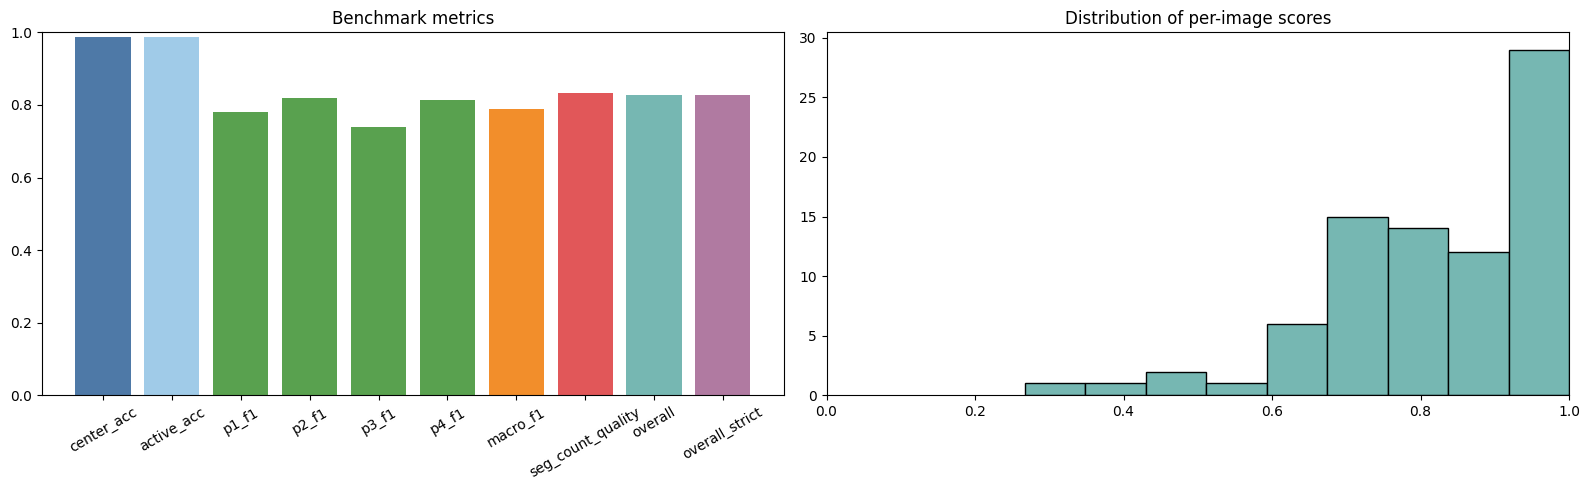


Worst-performing labeled images:
   L1000981: score=0.267, center(pred/true)=b_5/b_5, active(pred/true)=p2/p2
   L1000978: score=0.400, center(pred/true)=y_8/y_8, active(pred/true)=p3/p3
   L1000850: score=0.467, center(pred/true)=g_2/g_2, active(pred/true)=p1/p1
   L1000979: score=0.500, center(pred/true)=r_0/r_0, active(pred/true)=p1/p1
   L1000973: score=0.547, center(pred/true)=b_2/b_2, active(pred/true)=p3/p3
   L1000857: score=0.600, center(pred/true)=g_6/g_6, active(pred/true)=p3/p3
   L1000848: score=0.613, center(pred/true)=b_3/b_3, active(pred/true)=p4/p4

Top-performing labeled images:
   L1000770: score=1.000, center(pred/true)=y_1/y_1, active(pred/true)=p3/p3
   L1000771: score=1.000, center(pred/true)=r_5/r_5, active(pred/true)=p1/p1
   L1000773: score=1.000, center(pred/true)=y_8/y_8, active(pred/true)=p4/p4
   L1000779: score=1.000, center(pred/true)=b_7/b_7, active(pred/true)=p1/p1
   L1000781: score=1.000, center(pred/true)=g_8/g_8, active(pred/true)=p1/p1
   L100078

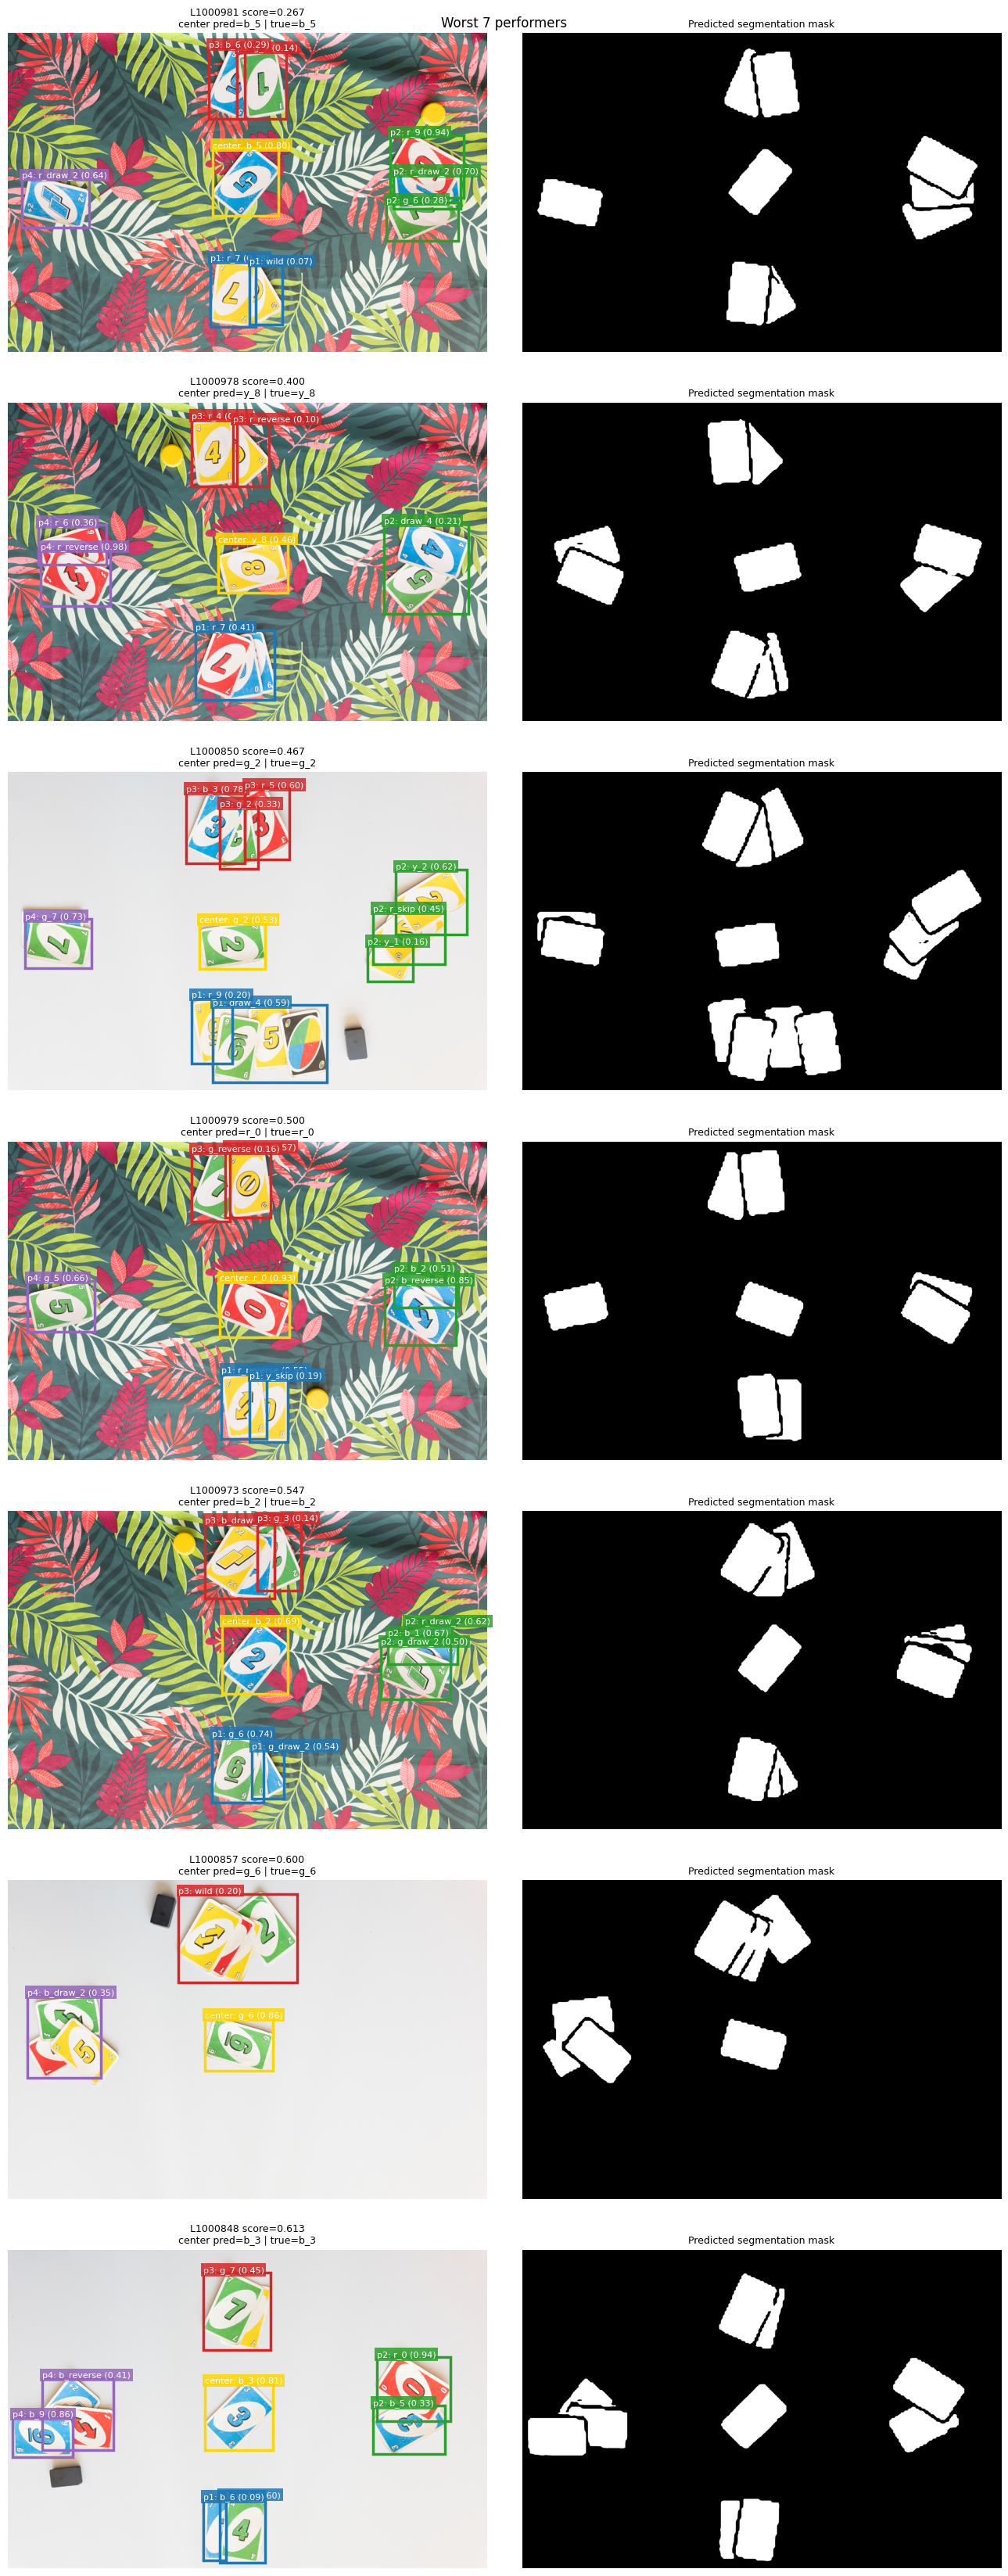

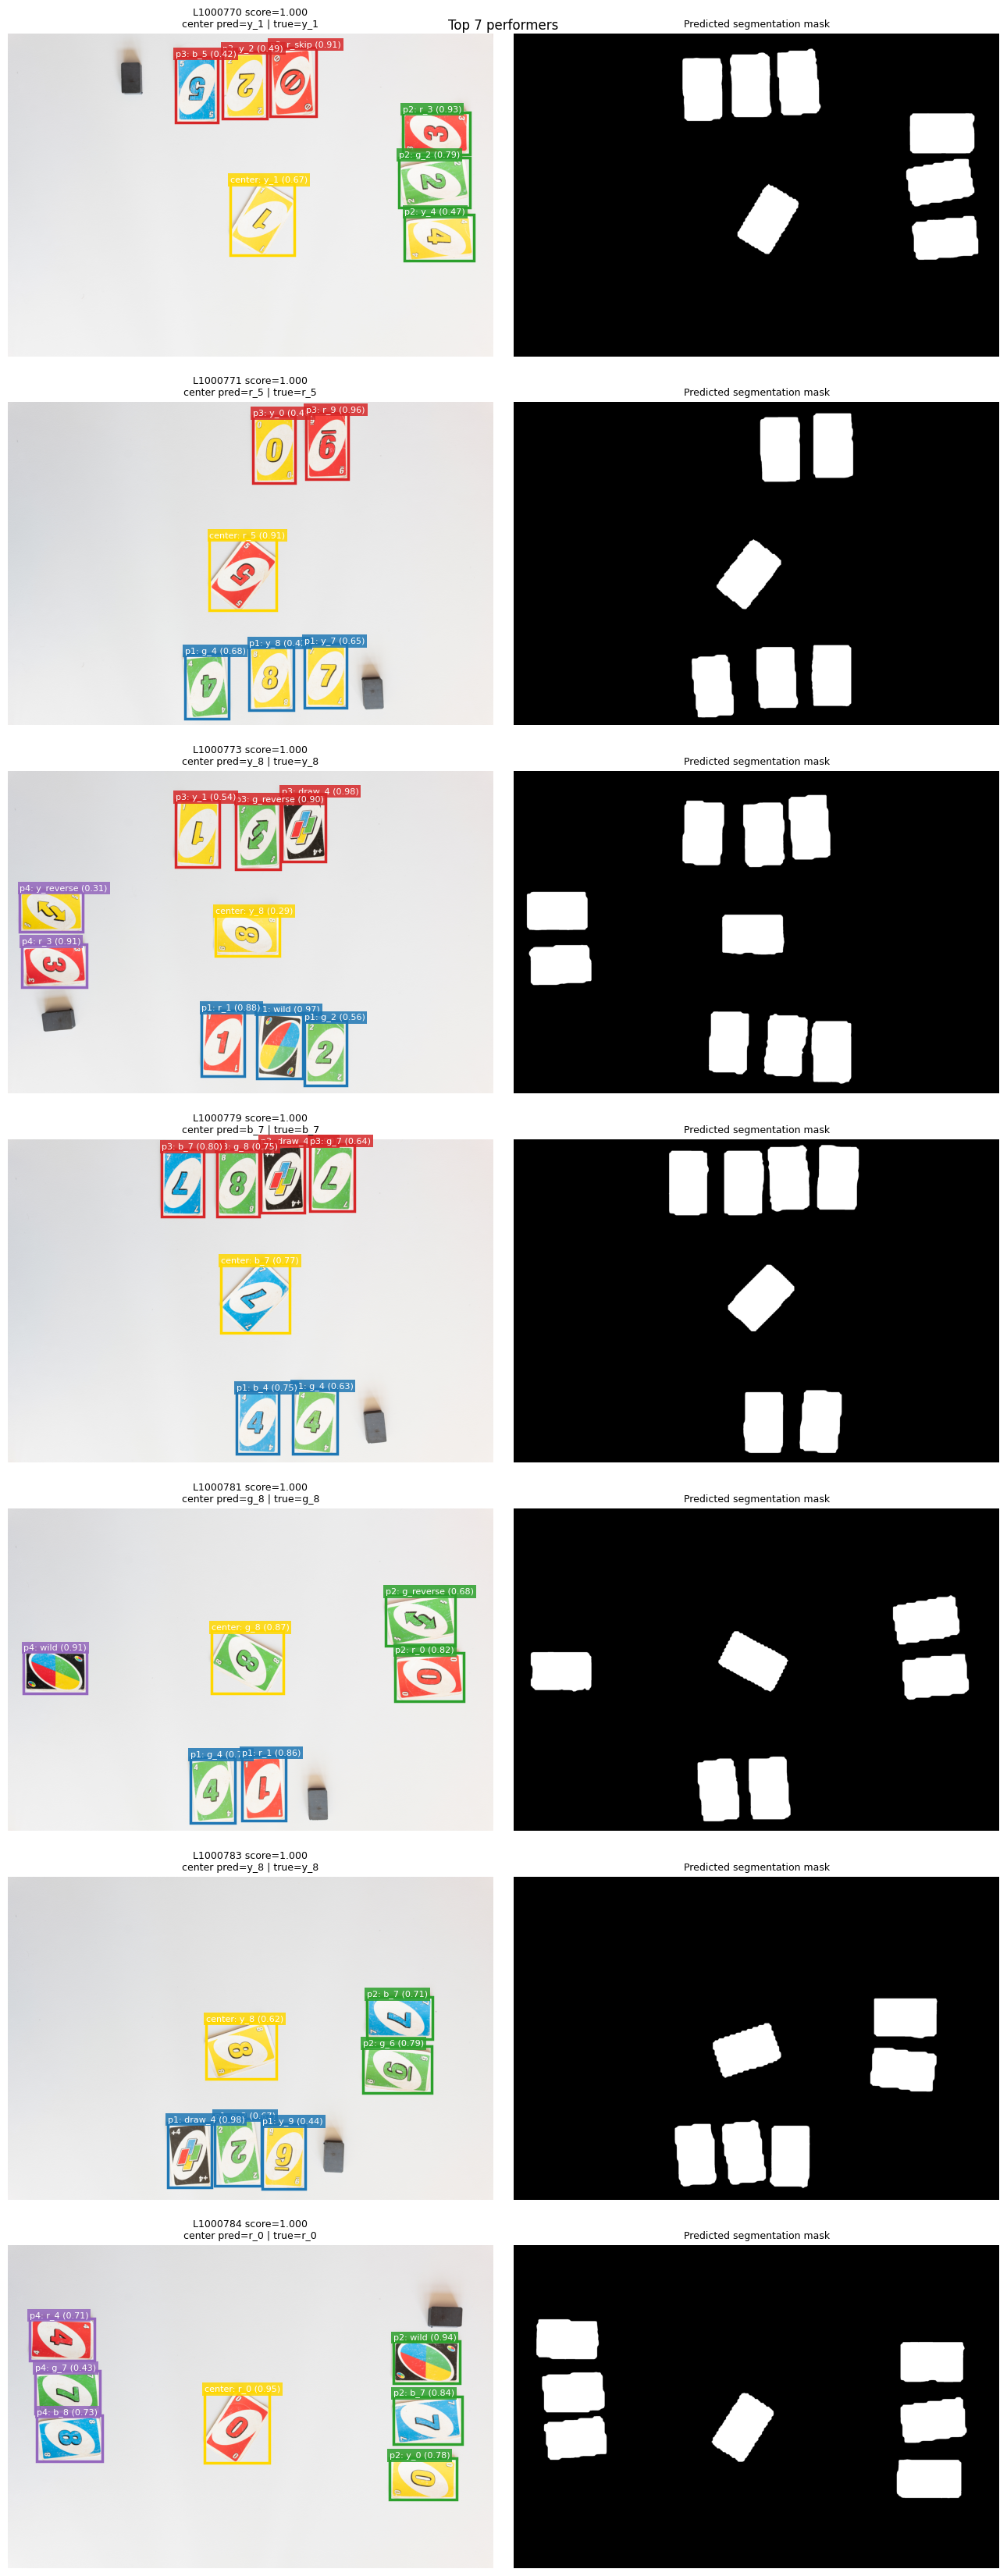

{'center_acc': 0.9876543209876543,
 'p1_f1': 0.7806584362139918,
 'p2_f1': 0.8193415637860083,
 'p3_f1': 0.7382716049382716,
 'p4_f1': 0.8128453850676074,
 'macro_f1': 0.7877792475014698,
 'overall': 0.8277542621987068,
 'overall_strict': 0.8285126396237509,
 'segmenter_count_quality': 0.8323045267489713,
 'avg_abs_card_count_diff': 0.5061728395061729,
 'avg_signed_card_count_diff': -0.4074074074074074,
 'avg_region_abs_card_count_diff': 0.5308641975308642,
 'cards_total_true': 627,
 'cards_total_pred': 594}

In [8]:
benchmark = run_labeled_benchmark(test_state, BENCHMARK_CFG)
{
    key: benchmark[key]
    for key in [
        "center_acc", "p1_f1", "p2_f1", "p3_f1", "p4_f1",
        "macro_f1", "overall", "overall_strict",
        "segmenter_count_quality", "avg_abs_card_count_diff",
        "avg_signed_card_count_diff", "avg_region_abs_card_count_diff",
        "cards_total_true", "cards_total_pred",
    ]
}

## Synthetic-Scene Check

In [9]:
benchmark["worst_results"][:5]

[{'image_id': 'L1000981',
  'image_path': WindowsPath('C:/Users/UdaRe/OneDrive/Documenti/GitHub/iapr2026do/data/iapr-26-uno-vision-challenge/train_images/L1000981.jpg'),
  'pred_summary': {'image_id': 'L1000981',
   'center_card': 'b_5',
   'active_player': 'p2',
   'player_1_cards': 'r_7;wild',
   'player_2_cards': 'r_9;g_6;r_draw_2',
   'player_3_cards': 'g_7;b_6',
   'player_4_cards': 'r_draw_2'},
  'true_summary': {'image_id': 'L1000981',
   'center_card': 'b_5',
   'active_player': 'p2',
   'player_1_cards': 'y_7;y_skip',
   'player_2_cards': 'g_7;b_4;r_9',
   'player_3_cards': 'b_5;g_1',
   'player_4_cards': 'b_draw_2'},
  'pred_rows': [{'box_index': 0,
    'box': (3195, 851, 3807, 1374),
    'label': 'r_9',
    'confidence': 0.940928041934967,
    'region': 'p2',
    'mask_coverage': 0.3565625},
   {'box_index': 1,
    'box': (1709, 960, 2260, 1529),
    'label': 'b_5',
    'confidence': 0.7989425659179688,
    'region': 'center',
    'mask_coverage': 0.3874609375},
   {'box_ind

## Game-State Style Summary

This formats CardUNet predictions into the same game-state style row structure:
one center card and one card list per player (`p1..p4`). Active-player prediction remains handled by the turn/token detector.

In [10]:
benchmark["top_results"][:5]

[{'image_id': 'L1000770',
  'image_path': WindowsPath('C:/Users/UdaRe/OneDrive/Documenti/GitHub/iapr2026do/data/iapr-26-uno-vision-challenge/train_images/L1000770.jpg'),
  'pred_summary': {'image_id': 'L1000770',
   'center_card': 'y_1',
   'active_player': 'p3',
   'player_1_cards': 'EMPTY',
   'player_2_cards': 'g_2;y_4;r_3',
   'player_3_cards': 'r_skip;y_2;b_5',
   'player_4_cards': 'EMPTY'},
  'true_summary': {'image_id': 'L1000770',
   'center_card': 'y_1',
   'active_player': 'p3',
   'player_1_cards': 'EMPTY',
   'player_2_cards': 'y_4;g_2;r_3',
   'player_3_cards': 'r_skip;y_2;b_5',
   'player_4_cards': 'EMPTY'},
  'pred_rows': [{'box_index': 0,
    'box': (1834, 1229, 2359, 1826),
    'label': 'y_1',
    'confidence': 0.6693457961082458,
    'region': 'center',
    'mask_coverage': 0.3634375},
   {'box_index': 1,
    'box': (3224, 1023, 3806, 1435),
    'label': 'g_2',
    'confidence': 0.7883234620094299,
    'region': 'p2',
    'mask_coverage': 0.4004296875},
   {'box_index

## Benchmark On Original Labeled Dataset (Masked Classifier)

> The official `test_images` split has no public labels, so true performance cannot be computed there. This section evaluates the full segmentation + masked classification pipeline on labeled images from `train.csv` (optionally on a subset), reports metrics, and visualizes worst/top examples.

In [11]:
# # Optional quick benchmark rerun on a subset.
# quick_benchmark_cfg = {
#     **BENCHMARK_CFG,
#     "eval_max_images": 100,
# }
# quick_benchmark = run_labeled_benchmark(test_state, quick_benchmark_cfg)
# quick_benchmark["overall"]